In [1]:
%matplotlib widget
import os, threading
import numpy as np
import h5py
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import ipywidgets as widgets

# ── Configuration ──
H5_PATH = '/mnt/c/Users/photo/Photonics_Group/Ruihuan/kubeflow-tdgl/notebooks/sim_output.h5'
NX, NY = 100, 50  # interpolation grid size
PREFETCH_AHEAD = 5
KEEP_BEHIND = 2
PLAYBACK_INTERVAL_MS = 100

print(f'HDF5: {H5_PATH}')
print(f'Exists: {os.path.exists(H5_PATH)}')


HDF5: /mnt/c/Users/photo/Photonics_Group/Ruihuan/kubeflow-tdgl/notebooks/sim_output.h5
Exists: True

In [2]:
class FrameSource:
    """Reads individual frames from an HDF5 file."""

    def __init__(self, h5_path: str, points: np.ndarray,
                 grid_pts: np.ndarray, nx: int, ny: int,
                 total_frames: int = None):
        self.h5_path = h5_path
        self.points = points
        self.grid_pts = grid_pts
        self.nx = nx
        self.ny = ny
        if total_frames is None:
            with h5py.File(h5_path, 'r') as f:
                self._total_frames = len(f['data'].keys())
        else:
            self._total_frames = total_frames

    def frame_exists(self, idx: int) -> bool:
        try:
            with h5py.File(self.h5_path, 'r') as f:
                return str(idx) in f['data']
        except Exception:
            return False

    def load_frame(self, idx: int) -> np.ndarray:
        """Load frame idx, return interpolated 2D array (ny, nx)."""
        with h5py.File(self.h5_path, 'r') as f:
            psi = np.abs(np.array(f[f'data/{idx}/psi']))
        Z = griddata(self.points, psi, self.grid_pts, method='cubic',
                     fill_value=0.0).reshape(self.ny, self.nx)
        return np.clip(Z, 0, None)

    @property
    def latest_available(self) -> int:
        try:
            with h5py.File(self.h5_path, 'r') as f:
                return len(f['data'].keys())
        except Exception:
            return 0

    @property
    def total_frames(self) -> int:
        return self._total_frames

    def build_interpolation_grid(self):
        """Return (gx, gy) arrays for heatmap axes."""
        xmin, xmax = self.points[:, 0].min(), self.points[:, 0].max()
        ymin, ymax = self.points[:, 1].min(), self.points[:, 1].max()
        return (np.linspace(xmin, xmax, self.nx),
                np.linspace(ymin, ymax, self.ny))

print('FrameSource defined')


FrameSource defined

In [3]:
class FrameCache:
    """Sliding window cache with background prefetch."""

    def __init__(self, source: FrameSource,
                 prefetch_ahead: int = 5, keep_behind: int = 2):
        self.source = source
        self.prefetch_ahead = prefetch_ahead
        self.keep_behind = keep_behind
        self._cache: dict[int, np.ndarray] = {}
        self._lock = threading.Lock()

    def get(self, idx: int) -> np.ndarray | None:
        with self._lock:
            return self._cache.get(idx)

    def ensure(self, idx: int) -> np.ndarray:
        """Blocking: load frame if not cached, prefetch ahead, evict behind."""
        with self._lock:
            if idx in self._cache:
                frame = self._cache[idx]
            else:
                frame = None

        if frame is None:
            frame = self.source.load_frame(idx)
            with self._lock:
                self._cache[idx] = frame

        self.evict(idx - self.keep_behind)
        self.prefetch(idx + 1, self.prefetch_ahead)
        return frame

    def prefetch(self, from_idx: int, count: int) -> None:
        """Background thread: load count frames starting from from_idx."""
        def _worker():
            for i in range(from_idx, from_idx + count):
                if i >= self.source.total_frames:
                    break
                with self._lock:
                    if i in self._cache:
                        continue
                if not self.source.frame_exists(i):
                    continue
                frame = self.source.load_frame(i)
                with self._lock:
                    self._cache[i] = frame

        t = threading.Thread(target=_worker, daemon=True)
        t.start()

    def evict(self, before_idx: int) -> None:
        """Remove frames with index < before_idx."""
        with self._lock:
            to_remove = [k for k in self._cache if k < before_idx]
            for k in to_remove:
                del self._cache[k]

    @property
    def cached_indices(self) -> list[int]:
        with self._lock:
            return sorted(self._cache.keys())

print('FrameCache defined')


FrameCache defined

In [9]:
import tornado.ioloop


class FramePlayer:
    """Playback controller with ipympl rendering and ipywidgets controls."""

    def __init__(self, source: FrameSource, cache: FrameCache,
                 interval_ms: int = 100):
        self.source = source
        self.cache = cache
        self._interval = interval_ms / 1000.0
        self._playing = False
        self._current = 0
        self._latest = source.latest_available
        self._timer = None
        self._poller = None

        # Interpolation grid axes
        gx, gy = source.build_interpolation_grid()
        xmin, xmax = gx[0], gx[-1]
        ymin, ymax = gy[0], gy[-1]

        # Initial frame
        Z0 = cache.ensure(0)

        # ipympl figure (ioff prevents auto-display, we show via VBox)
        with plt.ioff():
            self.fig, self.ax = plt.subplots(figsize=(10, 4), dpi=100)
        self.im = self.ax.imshow(
            Z0, extent=[xmin, xmax, ymin, ymax],
            origin='lower', cmap='inferno',
            vmin=0, vmax=1.05, aspect='equal',
        )
        self.fig.colorbar(self.im, ax=self.ax, label='|ψ|',
                          pad=0.02, shrink=0.9)
        self.title = self.ax.set_title(
            f'Frame 0 / {source.total_frames}', fontsize=11,
            fontweight='bold')
        self.ax.set_xlabel('x')
        self.ax.set_ylabel('y')
        self.fig.tight_layout()

        # Widgets
        self.btn = widgets.ToggleButton(
            value=False, description='▶',
            tooltip='Play / Pause', button_style='',
            layout=widgets.Layout(width='50px'),
        )
        self.slider = widgets.IntSlider(
            value=0, min=0, max=max(self._latest - 1, 0),
            step=1, description='',
            continuous_update=False,
            layout=widgets.Layout(flex='1', min_width='300px'),
        )
        self.label = widgets.Label(
            value=f'0 / {source.total_frames}',
            layout=widgets.Layout(width='100px'),
        )

        # Wire callbacks
        self.btn.observe(self._on_btn, names='value')
        self.slider.observe(self._on_slider, names='value')

        # Layout
        self.controls = widgets.HBox([self.btn, self.slider, self.label])
        self.ui = widgets.VBox([self.controls, self.fig.canvas])

        # Start polling for new frames
        self._schedule_poll()

    # ── Public API ──

    def show(self):
        """Display the player UI."""
        display(self.ui)

    def play(self):
        self._playing = True
        self.btn.value = True
        self.btn.description = '⏸'
        self._schedule_tick()

    def pause(self):
        self._playing = False
        self.btn.value = False
        self.btn.description = '▶'
        if self._timer:
            self._timer.cancel()
            self._timer = None

    def jump(self, idx: int):
        idx = max(0, min(idx, self.source.total_frames - 1))
        if self.source.frame_exists(idx):
            self._current = idx
        else:
            self._current = min(self._latest - 1, idx)
        self._render()
        if self._playing:
            self._schedule_tick()

    # ── Internals ──

    def _on_btn(self, change):
        if change['new']:
            self.play()
        else:
            self.pause()

    def _on_slider(self, change):
        self.jump(change['new'])

    def _schedule_tick(self):
        if self._timer:
            self._timer.cancel()
        self._timer = threading.Timer(self._interval, self._threadsafe_tick)
        self._timer.daemon = True
        self._timer.start()

    def _threadsafe_tick(self):
        # Schedule _tick on the IOLoop thread for thread-safe UI updates
        try:
            loop = tornado.ioloop.IOLoop.current(instance=False)
            if loop:
                loop.add_callback(self._tick)
            else:
                self._tick()
        except Exception:
            self._tick()

    def _tick(self):
        if not self._playing:
            return
        next_idx = self._current + 1
        if next_idx >= self.source.total_frames:
            self.pause()
            return
        if not self.source.frame_exists(next_idx):
            self._timer = threading.Timer(0.2, self._threadsafe_tick)
            self._timer.daemon = True
            self._timer.start()
            return
        self._current = next_idx
        self._render()
        self._schedule_tick()

    def _render(self):
        Z = self.cache.ensure(self._current)
        self.im.set_data(Z)
        self.title.set_text(
            f'|ψ|  frame {self._current} / {self.source.total_frames}')
        self.slider.value = self._current
        self.label.value = f'{self._current} / {self.source.total_frames}'
        self.fig.canvas.draw_idle()

    def _schedule_poll(self):
        self._poller = threading.Timer(2.0, self._poll_new_frames)
        self._poller.daemon = True
        self._poller.start()

    def _poll_new_frames(self):
        self._latest = self.source.latest_available
        if self._latest > 0:
            self.slider.max = self._latest - 1
        if self._latest < self.source.total_frames:
            self._schedule_poll()

print('FramePlayer defined')


FramePlayer defined

Source: 3376 frames, 3376 available
Grid: 860 mesh points -> 100x50 interpolation

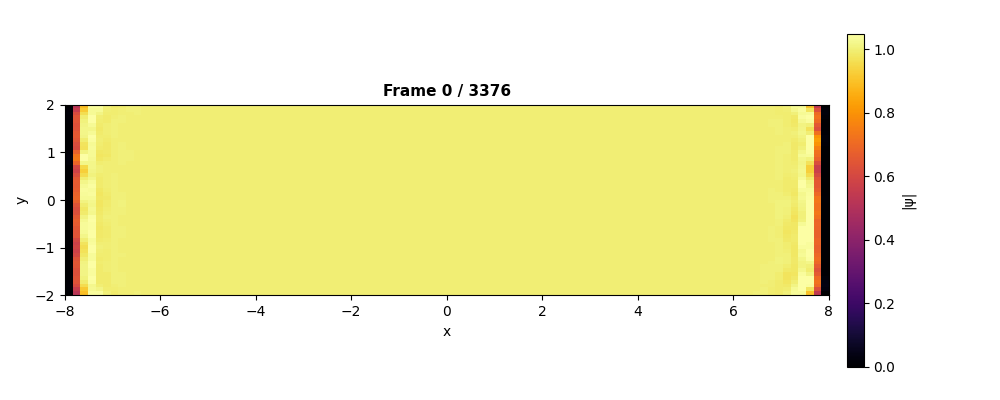

In [10]:
# ── Instantiate and display ──

# Extract mesh points from HDF5
with h5py.File(H5_PATH, 'r') as f:
    _points = np.array(f['solution/device/mesh/sites'])

# Build interpolation grid points
_xmin, _xmax = _points[:, 0].min(), _points[:, 0].max()
_ymin, _ymax = _points[:, 1].min(), _points[:, 1].max()
_gx = np.linspace(_xmin, _xmax, NX)
_gy = np.linspace(_ymin, _ymax, NY)
_GX, _GY = np.meshgrid(_gx, _gy)
_grid_pts = np.column_stack([_GX.ravel(), _GY.ravel()])

# Build components
source = FrameSource(H5_PATH, _points, _grid_pts, NX, NY)
cache = FrameCache(source, prefetch_ahead=PREFETCH_AHEAD,
                   keep_behind=KEEP_BEHIND)
player = FramePlayer(source, cache, interval_ms=PLAYBACK_INTERVAL_MS)

print(f'Source: {source.total_frames} frames, {source.latest_available} available')
print(f'Grid: {_points.shape[0]} mesh points -> {NX}x{NY} interpolation')
player.show()
